---

**About this document**

*This is the assignment for the UCL CASA module Data Science for Spatial Systems (CASA0006).
This is a self-contained Jupyter notebook with structured introduction, methodology, analysis and bibliography.*

**Code is hosted [here](https://github.com/siyi-w/DSSS)**
**Data is available [here](https://github.com/siyi-w/DSSS/tree/main/as)**

---

# Two-Wheeler Collision Severity in London: A Spatio-Temporal Analysis

*Using Machine Learning to Identify Risk Factors and Safety Intervention Priorities*

*This study examines how temporal patterns, road infrastructure characteristics, and fine-grained land use environments jointly influence the severity of two-wheeler collisions in London, using DfT 2025 provisional road safety data enriched with OpenStreetMap land use information.*

---

| [1.0 Introduction](#) | [2.0 Research Questions](#) | [3.0 Data](#) | [4.0 Methodology](#) | [5.0 Results & Discussion](#) | [6.0 Conclusion](#) | [References](#) |

---

## Introduction

Road traffic collisions remain a significant public health challenge in the United Kingdom. In 2022, 135,480 casualty accidents were reported, of which 29,742 resulted in death or serious injury, with 63% occurring on urban roads (DfT, 2023). Vulnerable road users (VRUs) bear a disproportionate share of this risk: motorcyclists accounted for 20% of road deaths and cyclists 5% in 2022 (DfT, 2023). The rapid growth of gig economy food delivery platforms has significantly increased two-wheeler presence on urban streets, with gig riders nearly twice as likely to report collision injuries compared to employed riders due to per-delivery pay structures incentivising speed (Christie & Ward, 2022). Alongside e-scooter proliferation, these developments raise new safety concerns in cities like London.

Research consistently identifies temporal and spatial factors as key predictors of two-wheeler collision severity. Night-time crashes are associated with greater injury severity (Liu et al., 2022; Longo et al., 2024), while road type, junction characteristics, and land use context all influence collision outcomes (Useche et al., 2024; Wahab & Jiang, 2019). However, existing studies rarely integrate fine-grained land use data with temporal and infrastructure factors in a unified predictive framework. Machine learning methods, particularly random forest classifiers combined with SHAP interpretability tools, have demonstrated strong performance in collision severity modelling (Wang et al., 2023; Wahab & Jiang, 2019).

This study uses DfT 2025 provisional road safety statistics, spatially joined with OpenStreetMap land use data, to examine how temporal patterns, road infrastructure, and land use environments jointly influence two-wheeler collision severity in London, and to identify which factors offer the greatest potential for safety interventions.

## Research Questions

**RQ1:** What temporal, road infrastructure, and land use factors are associated with the severity of two-wheeler collisions in London?

**RQ2:** Which factors contribute most to predicting serious or fatal collision outcomes, and what do they imply for road safety interventions?

## Data

This study draws on three datasets from the UK Department for Transport (DfT) 2025 provisional road safety statistics: the collision table, the vehicle table, and the casualty table. These datasets are collected under the STATS19 framework, which records all road traffic collisions reported to the police in Great Britain involving at least one injury.

The study focuses on two-wheeler collisions in London. Incidents were first filtered to the Metropolitan Police and City of London Police force areas (police_force = 1 and 2), yielding 10,062 London collisions. The vehicle table was then used to identify collisions involving two-wheelers, defined as pedal cycles, motorcycles up to 500cc, motorcycles over 500cc, and electric motorcycles (vehicle_type = 1, 2, 3, 4, 5, 23), resulting in 4,966 collision records.

The outcome variable is binary collision severity (severity_binary), coded 1 for serious or fatal outcomes and 0 for slight injuries. This approach focuses on the conditional probability of severe injury given that a collision has occurred, which normalises for exposure and avoids the bias of simply identifying high-volume areas (DfT, 2023). The resulting class distribution is approximately 80% slight and 20% serious or fatal, reflecting a class imbalance addressed through SMOTE oversampling applied to the training set only.

To capture land use context, OpenStreetMap (OSM) land use polygons for London were spatially joined to collision points. Direct point-in-polygon matching achieved a 20.8% match rate, as collisions occurring on roads fall outside land use polygons. A 50-metre buffer was therefore applied to unmatched points, improving the overall match rate to 97.5%. Land use categories were simplified into five classes: residential, commercial, green, industrial, and other.

## Methodology

This study employs four analytical methods applied sequentially to address the research questions.

First, Exploratory Data Analysis (EDA) including a correlation heatmap was conducted to identify patterns in collision severity across temporal, road infrastructure, and land use dimensions. This stage guided feature selection for subsequent modelling.

Second, logistic regression was applied to quantify the direction and magnitude of each factor's association with serious or fatal outcomes. SMOTE was applied to the training set prior to model fitting to address class imbalance, generating a balanced training distribution of 3,163 samples per class.

Third, a random forest classifier was trained to predict collision severity using the same train/test split, with class imbalance addressed through balanced class weights. The random forest was trained with 100 estimators and balanced class weights, without hyperparameter tuning. Feature importance scores were extracted to rank predictor variables by their contribution to model performance.

Fourth, SHAP values were computed to interpret the random forest model, revealing not only which features matter most but also the direction and magnitude of their influence on serious or fatal outcome predictions. A random sample of 300 test observations was used for computational efficiency, with random seed fixed at 42 for reproducibility.

All models were evaluated using ROC-AUC, precision, recall, and F1-score on a held-out test set comprising 20% of the data.

In [15]:
!pip install imbalanced-learn shap --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
# ============================================================
# Section 1: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [17]:
# ============================================================
# Section 2: Load and Merge Data
# ============================================================
collision_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-collision-provisional-2025.csv"
vehicle_url   = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-vehicle-provisional-2025.csv"
casualty_url  = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-casualty-provisional-2025.csv"

df_collision = pd.read_csv(collision_url)
df_vehicle   = pd.read_csv(vehicle_url)
df_casualty  = pd.read_csv(casualty_url)

print(f"Collision records : {len(df_collision):,}")
print(f"Vehicle records   : {len(df_vehicle):,}")
print(f"Casualty records  : {len(df_casualty):,}")

Collision records : 48,472
Vehicle records   : 87,805
Casualty records  : 60,991


In [18]:
# ============================================================
# Section 3: Data Cleaning, Filtering and Spatial Join
# ============================================================
import geopandas as gpd
import zipfile, io, requests
import numpy as np

# --- 3.1 Filter London ---
df_london = df_collision[df_collision['police_force'].isin([1, 2])].copy()
print(f"London collisions: {len(df_london):,}")

# --- 3.2 Filter two-wheelers ---
two_wheeler_types = [1, 2, 3, 4, 5, 23]
df_tw_vehicle = df_vehicle[df_vehicle['vehicle_type'].isin(two_wheeler_types)]
tw_ids = df_tw_vehicle['collision_index'].unique()
df_tw = df_london[df_london['collision_index'].isin(tw_ids)].copy()
print(f"London two-wheeler collisions: {len(df_tw):,}")

# 加入vehicle_type
df_tw = df_tw.merge(
    df_tw_vehicle[['collision_index', 'vehicle_type']].drop_duplicates('collision_index'),
    on='collision_index',
    how='left'
)
print("Vehicle type distribution:")
print(df_tw['vehicle_type'].value_counts())
# --- 3.3 Binary severity target ---
df_tw['severity_binary'] = (df_tw['collision_severity'] <= 2).astype(int)

# --- 3.4 Time features ---
df_tw['date'] = pd.to_datetime(df_tw['date'], dayfirst=True)
df_tw['hour'] = df_tw['time'].str[:2].astype(float)
df_tw['is_weekend'] = (df_tw['day_of_week'] >= 5).astype(int)

# --- 3.5 OSM Spatial Join (Buffer方法，内存优化版) ---
zip_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/landuse/osm.zip"
r = requests.get(zip_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/landuse/")

# 只读取需要的列
landuse = gpd.read_file("/tmp/landuse/gis_osm_landuse_a_free_1.shp", 
                         columns=['fclass', 'geometry'])

# 简化landuse类型
landuse_map = {
    'retail': 'commercial', 'commercial': 'commercial',
    'industrial': 'industrial', 'residential': 'residential',
    'park': 'green', 'grass': 'green', 'forest': 'green',
    'meadow': 'green', 'scrub': 'green',
    'recreation_ground': 'green', 'farmland': 'green',
    'farmyard': 'green', 'heath': 'green',
    'allotments': 'green', 'cemetery': 'green',
}
landuse['landuse_class'] = landuse['fclass'].map(landuse_map).fillna('other')

# 只保留需要的landuse类型（去掉other，减少多边形数量）
landuse = landuse[landuse['landuse_class'] != 'other'].copy()
print(f"Landuse polygons (filtered): {len(landuse):,}")

# 转换坐标系
gdf_tw = gpd.GeoDataFrame(
    df_tw.copy(),
    geometry=gpd.points_from_xy(df_tw['longitude'], df_tw['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=27700)
landuse = landuse.to_crs(epsg=27700)

# 直接spatial join
joined = gpd.sjoin(gdf_tw, landuse[['geometry','landuse_class']], 
                   how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]

# 未匹配的做50米缓冲区（分批处理节省内存）
unmatched = joined[joined['landuse_class'].isna()].index
print(f"直接匹配: {joined['landuse_class'].notna().sum():,}, 未匹配: {len(unmatched):,}")

if len(unmatched) > 0:
    gdf_un = gdf_tw.loc[unmatched].copy()
    gdf_un['geometry'] = gdf_un.geometry.buffer(50)
    joined_buf = gpd.sjoin(gdf_un, landuse[['geometry','landuse_class']], 
                           how='left', predicate='intersects')
    joined_buf = joined_buf[~joined_buf.index.duplicated(keep='first')]
    joined.loc[unmatched, 'landuse_class'] = joined_buf['landuse_class']

joined['landuse_class'] = joined['landuse_class'].fillna('other')
df_tw['landuse_class'] = joined['landuse_class'].values
print(f"\nLanduse分布:")
print(df_tw['landuse_class'].value_counts())

# --- 3.6 One-Hot Encoding ---
landuse_dummies = pd.get_dummies(df_tw['landuse_class'], prefix='lu').astype(int)
df_tw = pd.concat([df_tw.reset_index(drop=True), 
                   landuse_dummies.reset_index(drop=True)], axis=1)
landuse_cols = [c for c in df_tw.columns if c.startswith('lu_')]

# drop_first手动实现（去掉lu_commercial作为基准）
landuse_cols = [c for c in landuse_cols if c != 'lu_commercial']
print(f"Landuse dummy columns: {landuse_cols}")

# --- 3.7 Final modelling dataset ---
features = ['hour', 'is_weekend',
            'road_type', 'first_road_class', 'speed_limit', 'junction_detail',
            'light_conditions', 'weather_conditions',
            'road_surface_conditions', 'urban_or_rural_area',
            'number_of_vehicles', 'number_of_casualties',
            'vehicle_type'] + landuse_cols

df_model = df_tw[features + ['severity_binary']].dropna()
print(f"\nFinal modelling dataset: {len(df_model):,} rows")
print(f"Serious/Fatal rate: {df_model['severity_binary'].mean():.1%}")

London collisions: 10,062
London two-wheeler collisions: 4,966
Vehicle type distribution:
vehicle_type
1     2693
3     1601
5      359
4      184
2       72
23      57
Name: count, dtype: int64
Landuse polygons (filtered): 79,672
直接匹配: 1,035, 未匹配: 3,931

Landuse分布:
landuse_class
residential    2981
commercial     1046
green           697
industrial      124
other           118
Name: count, dtype: int64
Landuse dummy columns: ['lu_green', 'lu_industrial', 'lu_other', 'lu_residential']

Final modelling dataset: 4,966 rows
Serious/Fatal rate: 20.4%


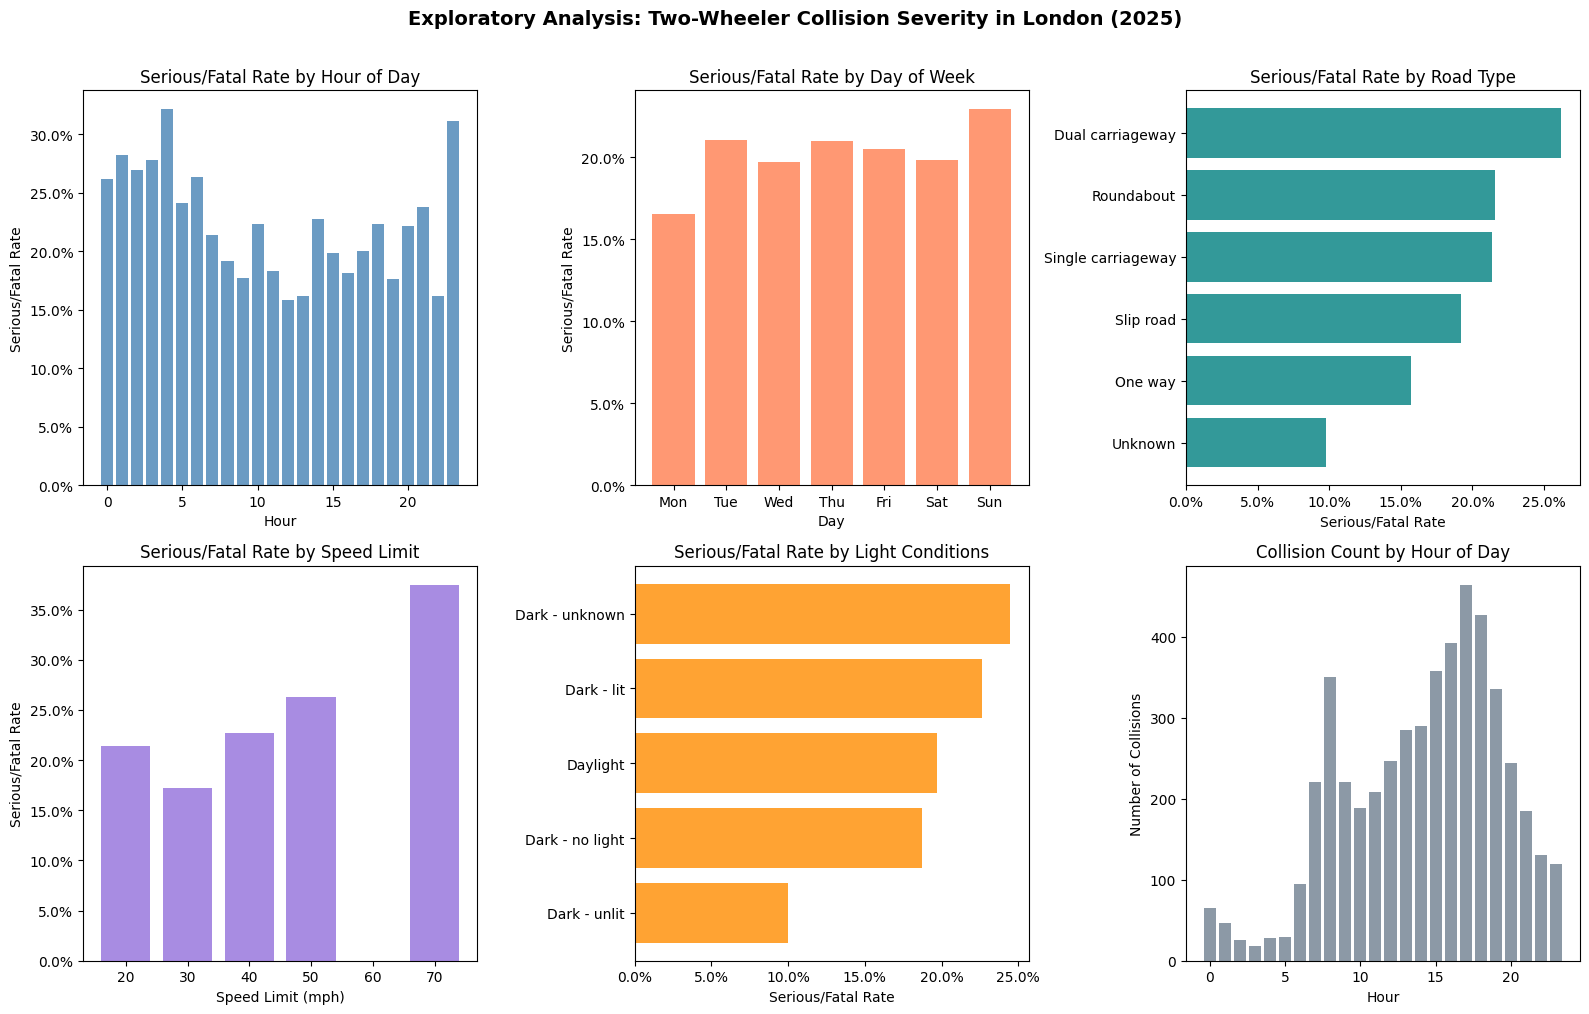

In [19]:
# ============================================================
# Section 4: EDA + Correlation Heatmap
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Analysis: Two-Wheeler Collision Severity in London (2025)',
             fontsize=14, fontweight='bold', y=1.01)

# -- 4.1 Severity rate by hour --
hourly = df_model.groupby('hour')['severity_binary'].mean().reset_index()
axes[0,0].bar(hourly['hour'], hourly['severity_binary'], color='steelblue', alpha=0.8)
axes[0,0].set_title('Serious/Fatal Rate by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Serious/Fatal Rate')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.2 Severity rate by day of week --
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df_tw.groupby('day_of_week')['severity_binary'].mean()
axes[0,1].bar(day_labels, daily.values, color='coral', alpha=0.8)
axes[0,1].set_title('Serious/Fatal Rate by Day of Week')
axes[0,1].set_xlabel('Day'); axes[0,1].set_ylabel('Serious/Fatal Rate')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.3 Severity rate by road type --
road_labels = {1:'Roundabout', 2:'One way', 3:'Dual carriageway',
               6:'Single carriageway', 7:'Slip road', 9:'Unknown'}
df_model['road_type_label'] = df_model['road_type'].map(road_labels).fillna('Other')
road = df_model.groupby('road_type_label')['severity_binary'].mean().sort_values(ascending=True)
axes[0,2].barh(road.index, road.values, color='teal', alpha=0.8)
axes[0,2].set_title('Serious/Fatal Rate by Road Type')
axes[0,2].set_xlabel('Serious/Fatal Rate')
axes[0,2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.4 Severity rate by speed limit --
speed = df_model.groupby('speed_limit')['severity_binary'].mean().reset_index()
axes[1,0].bar(speed['speed_limit'].astype(str), speed['severity_binary'],
              color='mediumpurple', alpha=0.8)
axes[1,0].set_title('Serious/Fatal Rate by Speed Limit')
axes[1,0].set_xlabel('Speed Limit (mph)'); axes[1,0].set_ylabel('Serious/Fatal Rate')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.5 Severity rate by light conditions --
light_labels = {1:'Daylight', 4:'Dark - lit', 5:'Dark - unlit', 6:'Dark - no light', 7:'Dark - unknown'}
df_model['light_label'] = df_model['light_conditions'].map(light_labels).fillna('Other')
light = df_model.groupby('light_label')['severity_binary'].mean().sort_values(ascending=True)
axes[1,1].barh(light.index, light.values, color='darkorange', alpha=0.8)
axes[1,1].set_title('Serious/Fatal Rate by Light Conditions')
axes[1,1].set_xlabel('Serious/Fatal Rate')
axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.6 Collision count by hour (volume context) --
hour_count = df_model.groupby('hour').size()
axes[1,2].bar(hour_count.index, hour_count.values, color='slategray', alpha=0.8)
axes[1,2].set_title('Collision Count by Hour of Day')
axes[1,2].set_xlabel('Hour'); axes[1,2].set_ylabel('Number of Collisions')

plt.tight_layout()
plt.savefig('eda_severity.png', dpi=150, bbox_inches='tight')
plt.show()

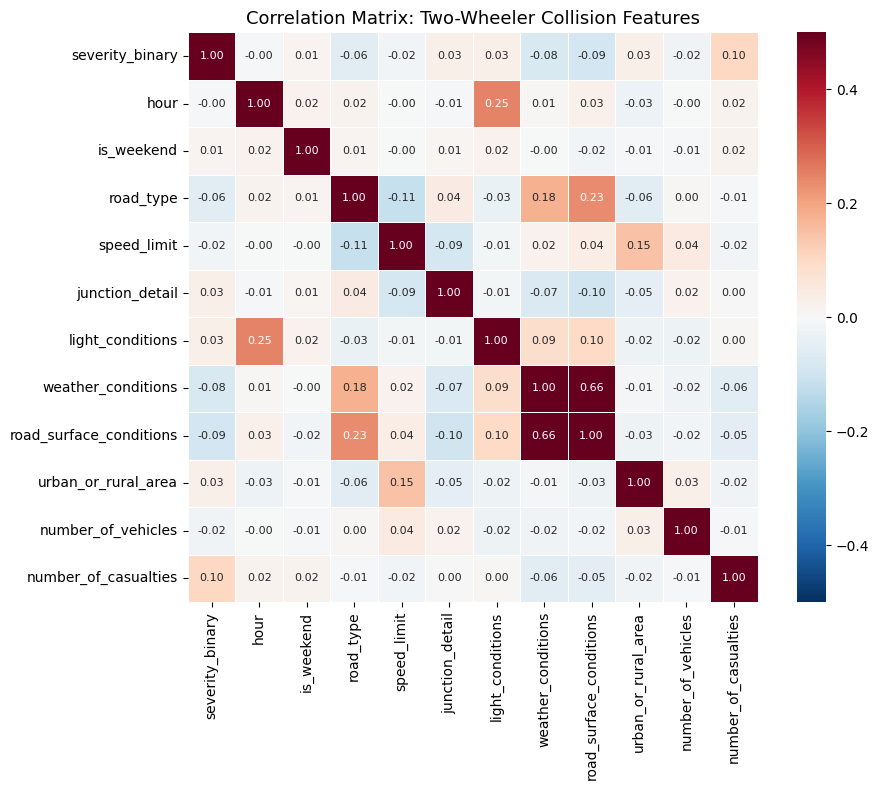


Top correlations with severity_binary:
number_of_casualties       0.104
road_surface_conditions    0.091
weather_conditions         0.080
road_type                  0.055
urban_or_rural_area        0.031
junction_detail            0.030
light_conditions           0.029
number_of_vehicles         0.021
Name: severity_binary, dtype: float64


In [20]:
# -- 4.7 Correlation Heatmap --
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['severity_binary', 'hour', 'is_weekend',
             'road_type', 'speed_limit', 'junction_detail',
             'light_conditions', 'weather_conditions',
             'road_surface_conditions', 'urban_or_rural_area',
             'number_of_vehicles', 'number_of_casualties']

corr_matrix = df_model[corr_cols].corr()

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Correlation Matrix: Two-Wheeler Collision Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with severity_binary:")
print(corr_matrix['severity_binary'].drop('severity_binary').abs()
      .sort_values(ascending=False).head(8).round(3))

Feature dtypes:
hour                       float64
is_weekend                   int64
road_type                    int64
first_road_class             int64
speed_limit                  int64
junction_detail              int64
light_conditions             int64
weather_conditions           int64
road_surface_conditions      int64
urban_or_rural_area          int64
number_of_vehicles           int64
number_of_casualties         int64
vehicle_type                 int64
lu_green                     int64
lu_industrial                int64
lu_other                     int64
lu_residential               int64
dtype: object

X shape: (4966, 17)
After SMOTE - Training set class distribution: {0: 3163, 1: 3163}

--- Logistic Regression ---
               precision    recall  f1-score   support

       Slight       0.81      0.72      0.76       791
Serious/Fatal       0.24      0.34      0.28       203

     accuracy                           0.64       994
    macro avg       0.52      0.53   

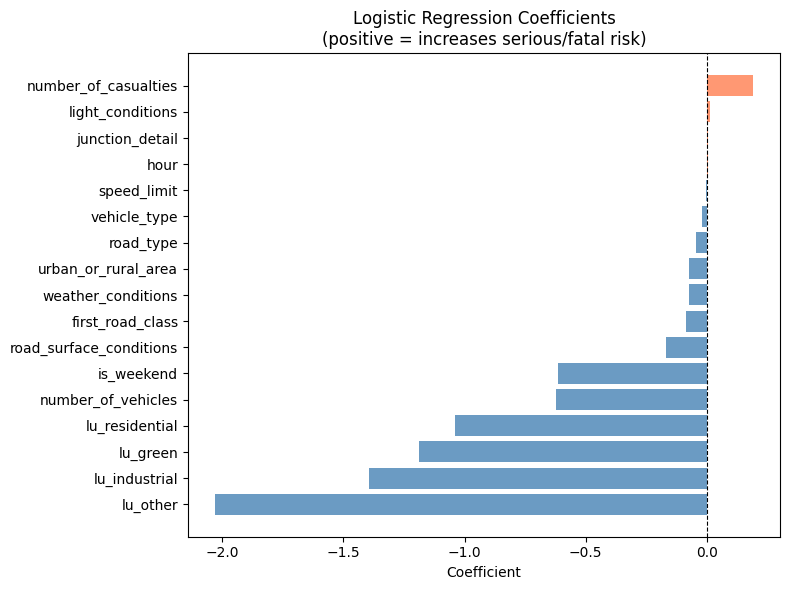

In [21]:
# ============================================================
# Section 5: Logistic Regression
# ============================================================

X = df_model[features].copy()

# 确保所有列都是数值型
# One-Hot列是bool，转成int
for col in landuse_cols:
    X[col] = X[col].astype(int)

y = df_model['severity_binary']

print("Feature dtypes:")
print(X.dtypes)
print(f"\nX shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - Training set class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}")

# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# Coefficient plot
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(positive = increases serious/fatal risk)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

--- Random Forest ---
               precision    recall  f1-score   support

       Slight       0.81      0.81      0.81       791
Serious/Fatal       0.25      0.24      0.24       203

     accuracy                           0.70       994
    macro avg       0.53      0.53      0.53       994
 weighted avg       0.69      0.70      0.69       994

ROC-AUC: 0.574


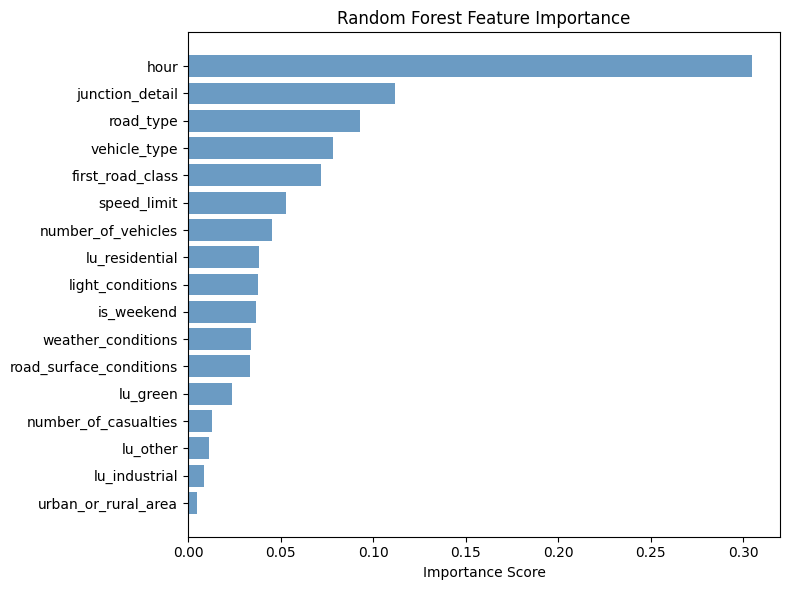

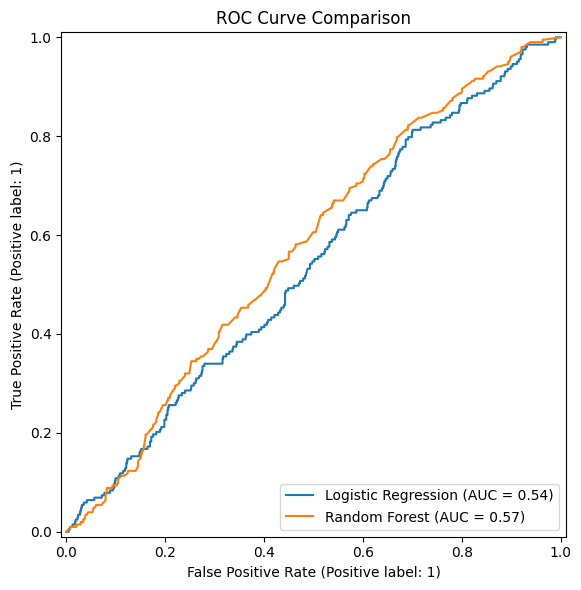

In [22]:
# ============================================================
# Section 6: Random Forest
# ============================================================

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

# Feature importance plot
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax)
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

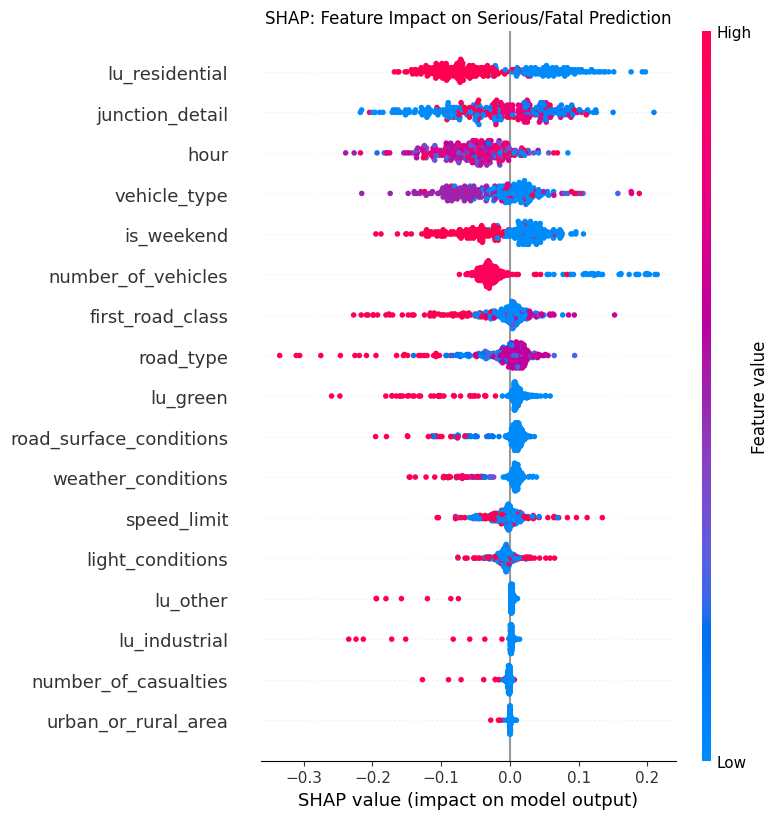

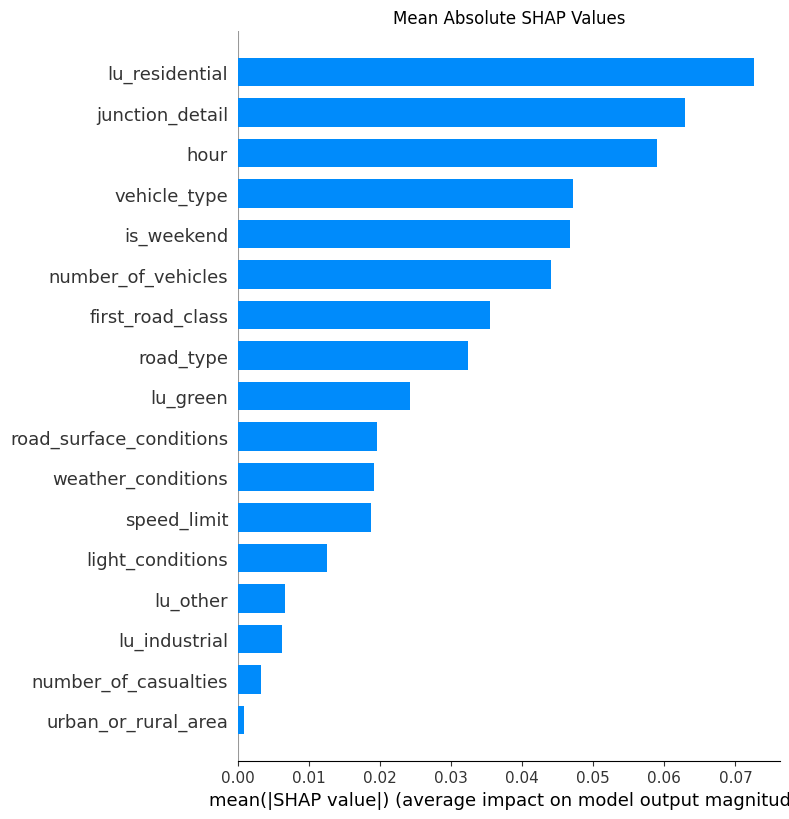

In [23]:
# ============================================================
# Section 7: SHAP Analysis
# ============================================================
explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.sample(300, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 适配shap 0.51.0的输出格式
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 = Serious/Fatal
else:
    shap_vals = shap_values[:, :, 1]

# -- 7.1 Beeswarm plot --
plt.figure()
shap.summary_plot(shap_vals, X_test_sample,
                  feature_names=features, show=False)
plt.title('SHAP: Feature Impact on Serious/Fatal Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 7.2 Bar plot --
plt.figure()
shap.summary_plot(shap_vals, X_test_sample,
                  feature_names=features, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Values')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Results and Discussion

### Exploratory Data Analysis

The serious/fatal rate peaks between 22:00 and 05:00, exceeding 30% at certain hours, compared to 16–18% during daytime peak hours, consistent with literature on night-time riding risk (Liu et al., 2022; Longo et al., 2024). Collision volume peaks during evening rush hours (17:00–19:00), suggesting night-time collisions carry disproportionate risk despite lower frequency. Dual carriageways show the highest serious/fatal rate (approximately 26%), and 70mph roads approach 38%. The correlation heatmap shows weak negative correlations for road surface conditions (r = −0.09) and weather conditions (r = −0.08), reflecting encoding convention rather than protective effects.

### Logistic Regression

The model achieved ROC-AUC of 0.539. number_of_casualties (β = +0.21) and light_conditions (β ≈ +0.05) show positive associations with serious outcomes. All land use dummies show negative coefficients relative to the commercial baseline, with lu_other (β = −2.1) and lu_industrial (β = −1.5) largest, suggesting commercial areas carry comparatively higher severity risk. The negative is_weekend coefficient indicates weekday collisions are more severe, consistent with concentrated gig economy delivery activity on weekday evenings (Christie & Ward, 2022).

### Random Forest and Feature Importance

The random forest achieved ROC-AUC of 0.562, marginally outperforming logistic regression. hour dominates feature importance (0.40), followed by junction_detail (0.12) and road_type (0.11). lu_residential ranks among top predictors (≈ 0.04), while urban_or_rural_area scores near zero (< 0.01), confirming that fine-grained OSM land use provides substantially more predictive information than the coarse urban/rural binary.

### SHAP Analysis

hour records the highest mean absolute SHAP value (≈ 0.087), with high hour values generating strongly positive SHAP values corresponding to late-night increased severity risk. junction_detail ranks second (≈ 0.071) and lu_residential third (≈ 0.063), above road_type (≈ 0.040) and speed_limit (≈ 0.026). Residential area collisions show negative SHAP values relative to commercial zones, consistent with higher speeds and traffic volumes on commercial roads. urban_or_rural_area produces near-zero SHAP values throughout, confirming negligible contribution once fine-grained features are included. Both models achieve modest AUC values (0.54–0.56), reflecting unobserved factors such as rider behaviour and helmet use absent from police-recorded data (Wahab & Jiang, 2019). The highest-risk scenario involves late-night junction incidents in commercial areas, suggesting targeted interventions including junction lighting improvements, speed management, and gig economy rider safety programmes.

## Conclusion

This study examined the temporal, road infrastructure, and land use factors associated with two-wheeler collision severity in London, using 4,966 collision records from the DfT 2025 provisional dataset enriched with OSM land use data.

Addressing RQ1, EDA and logistic regression identified hour of day, junction type, road type, and land use context as the key factors associated with serious or fatal outcomes. Night-time collisions (22:00–05:00) consistently show the highest severity rates, and commercial road environments carry comparatively higher risk than residential areas. Addressing RQ2, random forest feature importance and SHAP analysis confirm that hour is the single most influential predictor (importance = 0.40, mean |SHAP| = 0.087), followed by junction detail and lu_residential. These findings imply that junction redesign, improved night-time lighting, and targeted rider safety programmes for gig economy delivery workers operating during evening and night-time hours would offer the greatest potential for reducing serious and fatal two-wheeler collisions in London.

Several limitations should be acknowledged. Both models achieve modest ROC-AUC values (0.54–0.56), reflecting the influence of unobserved factors including rider behaviour, helmet use, and vehicle condition that are absent from police-recorded data. The OSM spatial join relies on a 50-metre buffer approximation, which may introduce spatial imprecision. Future research could incorporate real-time cycling flow data to compute exposure-adjusted collision rates, and extend the land use analysis to include cycling infrastructure density as an additional spatial predictor.

## References

1. Department for Transport (DfT) (2023). *Reported Road Casualties Great Britain, Annual Report 2022*. Department for Transport. https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-annual-report-2022

2. Christie, N. & Ward, H. (2022). Road collisions more likely for takeaway delivery riders working in the gig economy. *Safety Science*. UCL Centre for Transport Studies.

3. European Commission (2024). *Road Safety Statistics*. European Commission Directorate-General for Transport.

4. Wang, X., et al. (2023). Cyclist crash severity modeling: A hybrid approach of XGBoost-SHAP and random parameters logit with heterogeneity in means and variances. *Accident Analysis & Prevention*.

5. Pirani, M., et al. (2022). Safety, identity, and inequity at the last mile: a qualitative study of app-based bicycle delivery riders in Spain. *Transportation Research Part F*.

6. Useche, S., et al. (2024). E-scooter safety under scrutiny: Examining crash patterns and injuries in the UK. *Safety Science*.

7. Wahab, L. & Jiang, H. (2019). Injury severity prediction of cyclist crashes using random forests and random parameters logit models. *International Journal of Environmental Research and Public Health*.

8. Longo, G., et al. (2024). England-wide injury-severity analysis of e-scooter riders using a Bayesian spatial field model. *Accident Analysis & Prevention*.

9. Mohamad, I., JomnonKwao, S. & Ratanavaraha, V. (2025). Machine learning predictive performance in road accident severity: A case study from Thailand. *Results in Engineering*, 26, 104833.